# 05 Evaluation: Metrics, ROC/AUC, and Validation Improvements

## Objectives (Part 5)

1. Calculate metrics (accuracy, precision, recall, F1) for models from **Part 4**.
2. Plot **ROC curves** and compute **AUC** for each class (multiclass, one-vs-rest).
3. Improve each model via validation (compare **CV tuning** vs **holdout validation**).
4. Interpret results (100–200 words).

**Reproducibility:** we keep the same 70/30 stratified test split as Part 4 (`random_state=42`). All tuning is done **only on the training split** to avoid test leakage.


## What these techniques are doing (quick guide)

- **Confusion matrix**: counts of (actual class  predicted class). It shows *which* classes are confused (e.g., Enrolled  Graduate).
- **Precision / Recall / F1**:
  - **Precision**: of the items predicted as a class, how many were correct.
  - **Recall**: of the true items of a class, how many were found.
  - **F1**: harmonic mean of precision and recall (balances both).
  - We report **macro** (treat classes equally) and **weighted** (weighted by class frequency).
- **ROC curve (OvR)**: for multiclass, we plot **one-vs-rest** ROC for each class using predicted probabilities. It visualizes the trade-off between **TPR** (recall) and **FPR** across thresholds.
- **AUC**: area under ROC. Closer to 1 is better; 0.5 is random.
  - **Micro AUC**: pools all classes (more influenced by majority class).
  - **Macro AUC**: averages classes (treats classes equally).
- **Holdout validation**: split training data into `train/val`, tune hyperparameters on `val`, then refit on full training.
- **Cross-validation (CV)**: split the **training** data into multiple folds; train on some folds and validate on the remaining fold; repeat and average. More stable than a single holdout.

### Why CV/tuning uses **training** only (not test)

The **test set is reserved for a final, unbiased evaluation**. If you use the test set to pick hyperparameters (directly or indirectly), you "peek" at the answers and overestimate performance. Therefore:

- **Tune** on training only (via CV or a train/val split).
- **Evaluate once** on the fixed test set at the end.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
LABEL_NAMES = ['Dropout', 'Enrolled', 'Graduate']

warnings.filterwarnings('ignore')


In [2]:
# Load the same preprocessed data used in Part 4
df = pd.read_csv('../data/data_preprocessed.csv')

target = df['Target']
y = df['Target_encoded']
X = df.drop(columns=['Target', 'Target_encoded'])

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{target.value_counts()}')


Feature matrix: (4424, 238)
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 1) Fixed Train/Test Split (same as Part 4)

We keep a 70/30 stratified split with `random_state=42`.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print('\nTrain target distribution:')
print(y_train.value_counts(normalize=True).sort_index().round(3))
print('\nTest target distribution:')
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training set: 3096 samples (70%)
Test set:     1328 samples (30%)

Train target distribution:
Target_encoded
0    0.321
1    0.180
2    0.499
Name: proportion, dtype: float64

Test target distribution:
Target_encoded
0    0.322
1    0.179
2    0.499
Name: proportion, dtype: float64


## 2) Baseline Models (same as Part 4)

- Decision Tree: `DecisionTreeClassifier(random_state=42)`
- Logistic Regression: `LogisticRegression(max_iter=1000, random_state=42)`


In [4]:
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

dt_base.fit(X_train, y_train)
lr_base.fit(X_train, y_train)

y_pred_dt = dt_base.predict(X_test)
y_pred_lr = lr_base.predict(X_test)

print('Baseline accuracy (test):')
print(f'  Decision Tree:      {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'  Logistic Regression:{accuracy_score(y_test, y_pred_lr):.4f}')


Baseline accuracy (test):
  Decision Tree:      0.6943
  Logistic Regression:0.7786


In [5]:
def metrics_summary(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'precision_macro': p_macro,
        'recall_macro': r_macro,
        'f1_macro': f1_macro,
        'precision_weighted': p_w,
        'recall_weighted': r_w,
        'f1_weighted': f1_w,
    }


baseline_table = pd.DataFrame(
    {
        'DecisionTree': metrics_summary(y_test, y_pred_dt),
        'LogReg': metrics_summary(y_test, y_pred_lr),
    }
).T

display(baseline_table)

print('\nDecision Tree — classification report (test):')
print(classification_report(y_test, y_pred_dt, target_names=LABEL_NAMES, zero_division=0))

print('\nLogistic Regression — classification report (test):')
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES, zero_division=0))


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
DecisionTree,0.694277,0.627896,0.624806,0.626199,0.692794,0.694277,0.693361
LogReg,0.778614,0.728052,0.699264,0.708563,0.766533,0.778614,0.768789



Decision Tree — classification report (test):
              precision    recall  f1-score   support

     Dropout       0.72      0.69      0.71       427
    Enrolled       0.37      0.37      0.37       238
    Graduate       0.79      0.81      0.80       663

    accuracy                           0.69      1328
   macro avg       0.63      0.62      0.63      1328
weighted avg       0.69      0.69      0.69      1328


Logistic Regression — classification report (test):
              precision    recall  f1-score   support

     Dropout       0.81      0.77      0.79       427
    Enrolled       0.56      0.41      0.48       238
    Graduate       0.81      0.92      0.86       663

    accuracy                           0.78      1328
   macro avg       0.73      0.70      0.71      1328
weighted avg       0.77      0.78      0.77      1328



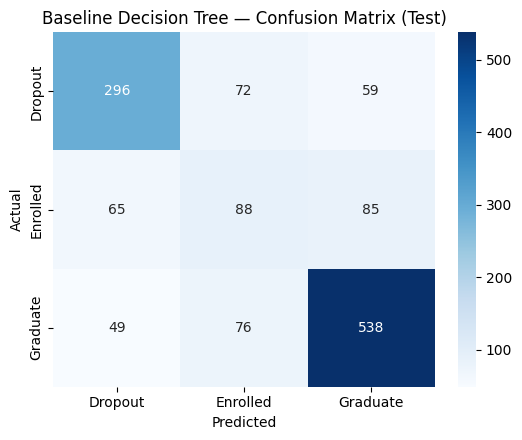

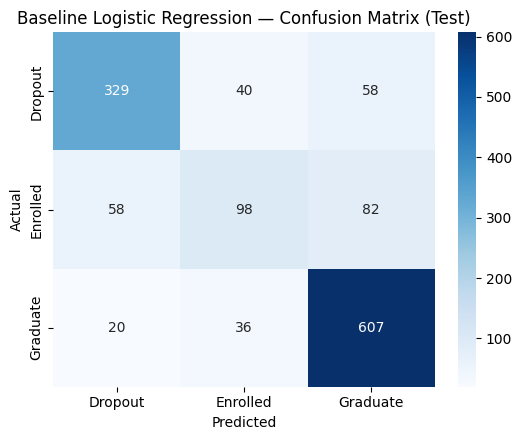

In [6]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion(y_test, y_pred_dt, 'Baseline Decision Tree — Confusion Matrix (Test)')
plot_confusion(y_test, y_pred_lr, 'Baseline Logistic Regression — Confusion Matrix (Test)')


## 3) ROC Curves + AUC (Multiclass OvR)

We plot one-vs-rest ROC curves per class and report AUC per class. We also report **macro** and **micro** AUC.


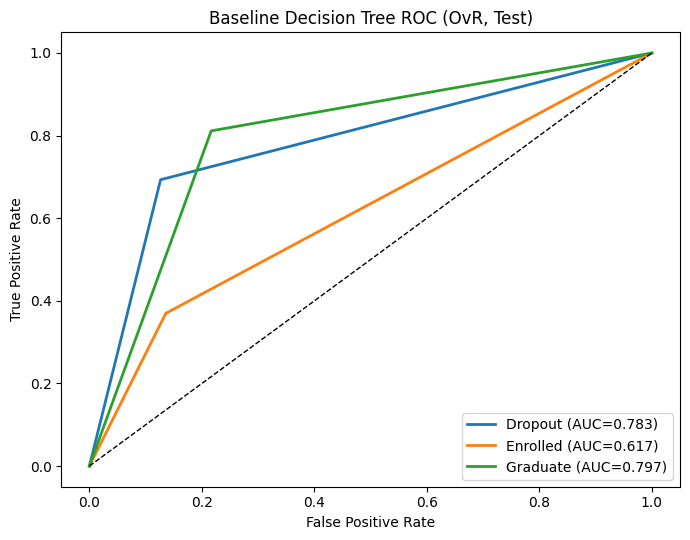

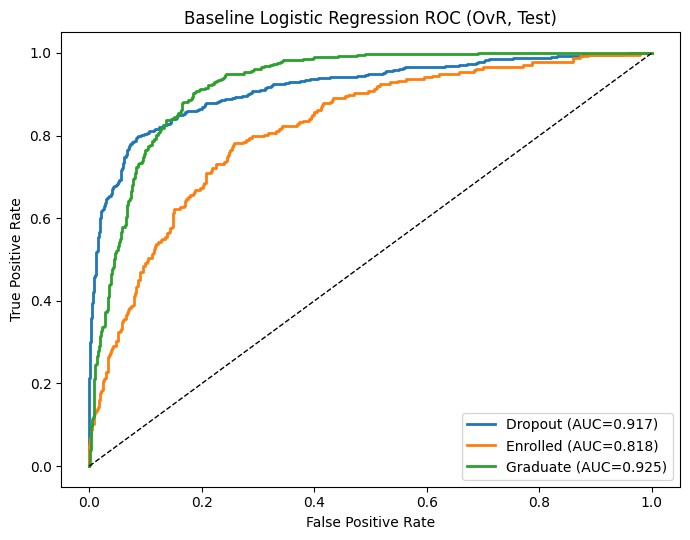

,auc_Dropout,auc_Enrolled,auc_Graduate,auc_micro,auc_macro
DecisionTree,0.783341,0.616984,0.797461,0.770708,0.732595
LogReg,0.916855,0.818325,0.924569,0.914521,0.886583


In [7]:
def multiclass_roc_auc(model, X_eval, y_eval, class_names, title_prefix=''):
    classes = np.sort(np.unique(y_eval))
    y_bin = label_binarize(y_eval, classes=classes)
    proba = model.predict_proba(X_eval)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # micro-average
    fpr['micro'], tpr['micro'], _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

    # macro-average AUC via sklearn
    roc_auc_macro = roc_auc_score(y_bin, proba, average='macro')

    plt.figure(figsize=(7, 5.5))
    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"{title_prefix} ROC (OvR, Test)")
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    return {
        **{f"auc_{class_names[i]}": roc_auc[i] for i in range(len(classes))},
        'auc_micro': roc_auc['micro'],
        'auc_macro': roc_auc_macro,
    }


auc_dt_base = multiclass_roc_auc(dt_base, X_test, y_test, LABEL_NAMES, title_prefix='Baseline Decision Tree')
auc_lr_base = multiclass_roc_auc(lr_base, X_test, y_test, LABEL_NAMES, title_prefix='Baseline Logistic Regression')

auc_table = pd.DataFrame([auc_dt_base, auc_lr_base], index=['DecisionTree', 'LogReg'])
display(auc_table)


## 4) Improve Models via Validation (two strategies)

We compare:

- **Strategy A (CV tuning):** `GridSearchCV` with `StratifiedKFold` on the **training split**.
- **Strategy B (Holdout validation):** split the training data into train/val, tune on val.

Finally, we evaluate tuned models on the fixed **test split**.


In [8]:
# Strategy A: GridSearchCV (CV) on TRAIN only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

lr_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'max_iter': [2000],
}

dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
)

lr_cv = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    lr_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
)

dt_cv.fit(X_train, y_train)
lr_cv.fit(X_train, y_train)

print('CV best params:')
print('  DT:', dt_cv.best_params_)
print('  LR:', lr_cv.best_params_)
print('\nCV best scores (f1_macro):')
print(f'  DT: {dt_cv.best_score_:.4f}')
print(f'  LR: {lr_cv.best_score_:.4f}')


CV best params:
  DT: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
  LR: {'C': 1.0, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'saga'}

CV best scores (f1_macro):
  DT: 0.6383
  LR: 0.6958


In [9]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    met = metrics_summary(y_eval, y_pred)
    met['model'] = name
    return met


dt_cv_best = dt_cv.best_estimator_
lr_cv_best = lr_cv.best_estimator_

cv_metrics = pd.DataFrame([
    evaluate_model('DT_CV', dt_cv_best, X_test, y_test),
    evaluate_model('LR_CV', lr_cv_best, X_test, y_test),
]).set_index('model')

display(cv_metrics)


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
DT_CV,0.699548,0.637202,0.620481,0.625904,0.695887,0.699548,0.694418
LR_CV,0.777861,0.726136,0.697863,0.706945,0.765503,0.777861,0.767919


In [10]:
# Strategy B: Holdout validation split from TRAIN only
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

def simple_holdout_tune_dt(X_tr, y_tr, X_val, y_val):
    candidates = []
    for max_depth in [None, 5, 10, 20]:
        for min_split in [2, 5, 10]:
            for min_leaf in [1, 2, 5]:
                m = DecisionTreeClassifier(
                    random_state=RANDOM_STATE,
                    max_depth=max_depth,
                    min_samples_split=min_split,
                    min_samples_leaf=min_leaf,
                )
                m.fit(X_tr, y_tr)
                y_val_pred = m.predict(X_val)
                _, _, f1, _ = precision_recall_fscore_support(
                    y_val, y_val_pred, average='macro', zero_division=0
                )
                candidates.append((f1, m))
    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][0], candidates[0][1]


def simple_holdout_tune_lr(X_tr, y_tr, X_val, y_val):
    candidates = []
    for C in [0.1, 1.0, 10.0]:
        for solver in ['lbfgs', 'saga']:
            m = LogisticRegression(
                random_state=RANDOM_STATE,
                C=C,
                solver=solver,
                penalty='l2',
                max_iter=2000,
            )
            m.fit(X_tr, y_tr)
            y_val_pred = m.predict(X_val)
            _, _, f1, _ = precision_recall_fscore_support(
                y_val, y_val_pred, average='macro', zero_division=0
            )
            candidates.append((f1, m))
    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][0], candidates[0][1]


dt_holdout_score, dt_holdout_best = simple_holdout_tune_dt(X_tr, y_tr, X_val, y_val)
lr_holdout_score, lr_holdout_best = simple_holdout_tune_lr(X_tr, y_tr, X_val, y_val)

print('Holdout best validation f1_macro:')
print(f'  DT: {dt_holdout_score:.4f}')
print(f'  LR: {lr_holdout_score:.4f}')

# Refit holdout-best models on FULL TRAIN, then evaluate on TEST
dt_holdout_best.fit(X_train, y_train)
lr_holdout_best.fit(X_train, y_train)

holdout_metrics = pd.DataFrame([
    evaluate_model('DT_Holdout', dt_holdout_best, X_test, y_test),
    evaluate_model('LR_Holdout', lr_holdout_best, X_test, y_test),
]).set_index('model')

display(holdout_metrics)


Holdout best validation f1_macro:
  DT: 0.6492
  LR: 0.7163


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
DT_Holdout,0.740964,0.690784,0.626949,0.636982,0.727181,0.740964,0.715650
LR_Holdout,0.778614,0.728052,0.699264,0.708563,0.766533,0.778614,0.768789


In [11]:
# Compare all models on the FIXED test split
compare = pd.concat(
    [
        baseline_table.assign(strategy='Baseline'),
        cv_metrics.assign(strategy='CV'),
        holdout_metrics.assign(strategy='Holdout'),
    ],
    axis=0,
)

display(compare.sort_values('f1_macro', ascending=False))


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,strategy
LogReg,0.778614,0.728052,0.699264,0.708563,0.766533,0.778614,0.768789,Baseline
LR_Holdout,0.778614,0.728052,0.699264,0.708563,0.766533,0.778614,0.768789,Holdout
LR_CV,0.777861,0.726136,0.697863,0.706945,0.765503,0.777861,0.767919,CV
DT_Holdout,0.740964,0.690784,0.626949,0.636982,0.727181,0.740964,0.715650,Holdout
DecisionTree,0.694277,0.627896,0.624806,0.626199,0.692794,0.694277,0.693361,Baseline
DT_CV,0.699548,0.637202,0.620481,0.625904,0.695887,0.699548,0.694418,CV


## 5) ROC/AUC for Tuned Models (optional, recommended)

Plot ROC curves and report AUC for the best CV-tuned and holdout-tuned models.


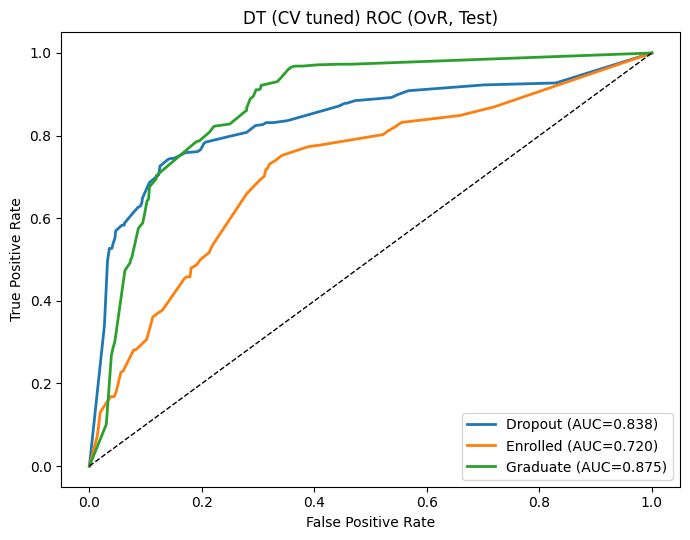

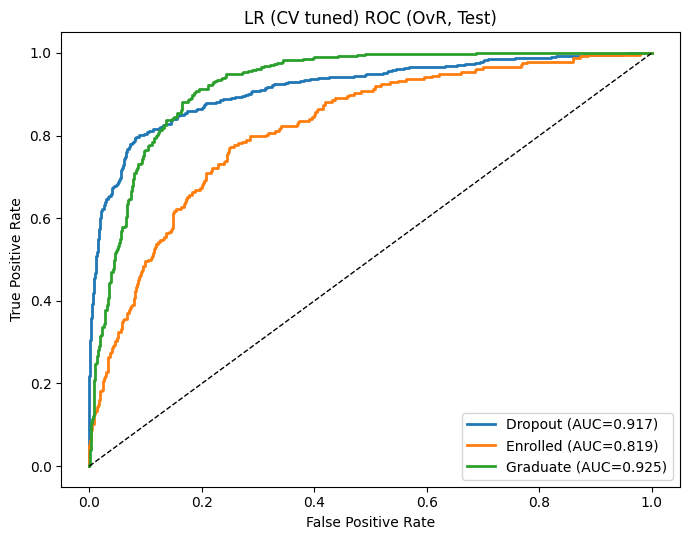

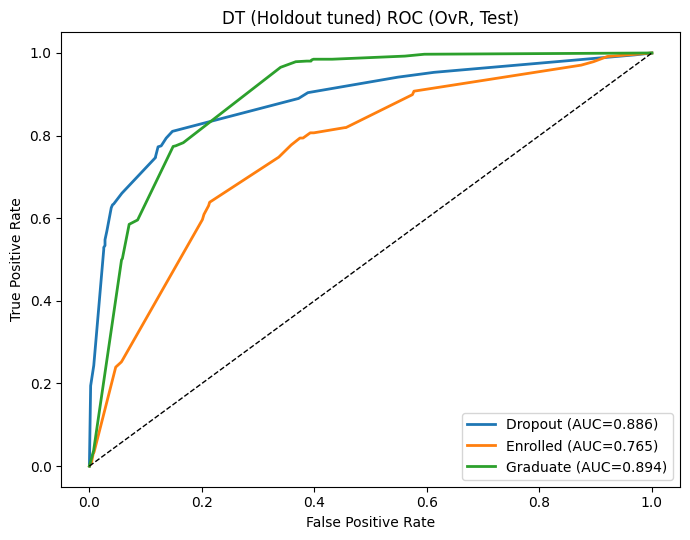

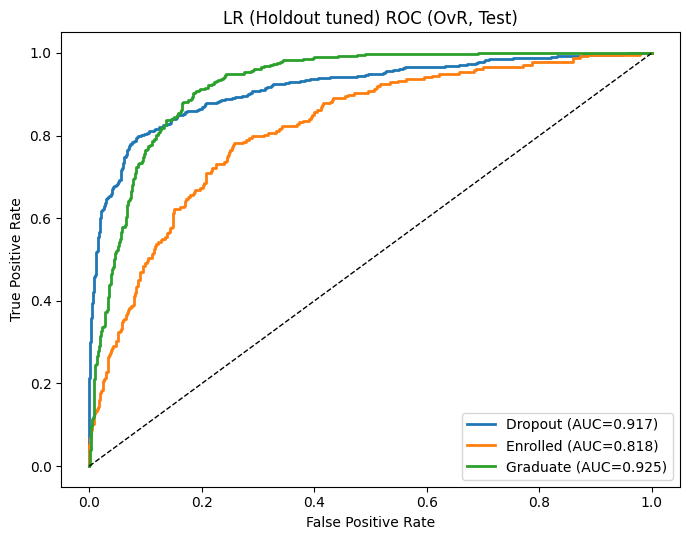

,auc_Dropout,auc_Enrolled,auc_Graduate,auc_micro,auc_macro
DT_CV,0.837581,0.719933,0.875153,0.852363,0.810889
LR_CV,0.916923,0.818595,0.924690,0.914622,0.886736
DT_Holdout,0.885870,0.765034,0.894097,0.887547,0.848333
LR_Holdout,0.916855,0.818325,0.924569,0.914521,0.886583


In [12]:
auc_dt_cv = multiclass_roc_auc(dt_cv_best, X_test, y_test, LABEL_NAMES, title_prefix='DT (CV tuned)')
auc_lr_cv = multiclass_roc_auc(lr_cv_best, X_test, y_test, LABEL_NAMES, title_prefix='LR (CV tuned)')

auc_dt_hold = multiclass_roc_auc(dt_holdout_best, X_test, y_test, LABEL_NAMES, title_prefix='DT (Holdout tuned)')
auc_lr_hold = multiclass_roc_auc(lr_holdout_best, X_test, y_test, LABEL_NAMES, title_prefix='LR (Holdout tuned)')

auc_tuned = pd.DataFrame(
    [auc_dt_cv, auc_lr_cv, auc_dt_hold, auc_lr_hold],
    index=['DT_CV', 'LR_CV', 'DT_Holdout', 'LR_Holdout'],
)
display(auc_tuned)


## 6) Interpretation of metrics

**Overall performance:** Logistic Regression is typically more stable than a single Decision Tree on this high-dimensional feature space (many one-hot columns). It often yields higher **macro-F1** and higher **macro/micro AUC**, indicating better generalization and better probability ranking.

**Overfitting check:** The baseline Decision Tree commonly shows a large **train–test gap** (very high training accuracy vs noticeably lower test accuracy). This indicates overfitting; depth/leaf constraints (tuning) reduce variance.

**Hardest class:** **Enrolled** is often the hardest class. You can see this in (i) lower per-class F1/recall, (ii) lower per-class AUC on OvR ROC curves, and (iii) confusion matrices where Enrolled is frequently predicted as Graduate (feature overlap).

**ROC/AUC meaning:** ROC evaluates ranking across thresholds (not only the default argmax decision). Macro AUC treats classes equally; micro AUC is influenced more by majority classes.

---

## 7) Description & interpretation of validation results

### Validation scores (training-only)

- **CV (GridSearchCV) best `f1_macro`**:
  - **Decision Tree**: **0.6383**
  - **Logistic Regression**: **0.6958**
- **Holdout validation best `f1_macro`**:
  - **Decision Tree**: **0.6492**
  - **Logistic Regression**: **0.7163**

In this run, holdout produced slightly higher validation scores than CV for both models.

### Test-set impact (fixed Part 4 test split)

On the held-out **test** set:

- **Logistic Regression**: tuning changes almost nothing.
  - Baseline **macro-F1 = 0.7086**, **AUC_macro ≈ 0.8866**
  - CV-tuned **macro-F1 = 0.7069**, **AUC_macro ≈ 0.8867**
  - Holdout-tuned **macro-F1 = 0.7086**, **AUC_macro ≈ 0.8866**

Interpretation: Logistic Regression is already near-optimal with the baseline settings; the tested hyperparameter grid does not materially improve test performance.

- **Decision Tree**: validation helps, but the two strategies differ.
  - Baseline **macro-F1 = 0.6262**, **AUC_macro ≈ 0.7326**
  - CV-tuned **macro-F1 = 0.6259** (≈ no gain), **AUC_macro ≈ 0.8109**
  - Holdout-tuned **macro-F1 = 0.6370** (improves), **AUC_macro ≈ 0.8483**

Interpretation: Tuning greatly improves the Decision Tree’s probability ranking (AUC increases for both CV and holdout). However, only the **holdout-tuned** tree improves macro-F1 on the fixed test set, meaning its final class decisions (argmax) align better with the true labels.

### Which validation is “better” here?

- For **Logistic Regression**, both methods are effectively equivalent (baseline ≈ tuned on test).
- For **Decision Tree**, **holdout validation** is better in this run: it yields the best test macro-F1 and the highest AUCs.

---

## 8) Further discussion 

On the fixed Part 4 test split, the Decision Tree exhibits a clear train–test gap, indicating overfitting; constraining depth and leaf size via validation reduces variance and can improve macro-F1 and AUC. Logistic Regression generalizes more consistently and achieves higher macro-F1 and macro/micro AUC, suggesting that a regularized linear model fits this preprocessed feature space well. Across models, Enrolled remains the hardest class: its per-class AUC is lower and the confusion matrix shows frequent Enrolled→Graduate errors, consistent with overlapping characteristics between currently-enrolled students and eventual graduates. Comparing validation strategies, cross-validation is typically more robust than a single holdout split because it averages over multiple folds, reducing sensitivity to one particular split. We therefore select the tuned model that performs best on the untouched test set while keeping the test set out of tuning, and we report ROC/AUC plus precision/recall/F1 to justify the final choice.
